## Soil spectroscopy (VIS-NIR-SWIR and MIR)

Following Wadoux's approach for exploratory soil spectra analysis:
- separate visualization by spectral domain,
- use mean curves to compare overall behavior,
- keep the inverted axis convention in MIR (decreasing wavenumber).

This notebook cell generates **two plots**:
1. VIS-NIR-SWIR (350-2500 nm)
2. MIR (4000-400 cm^-1)

C:\Users\PC\Desktop\RESET


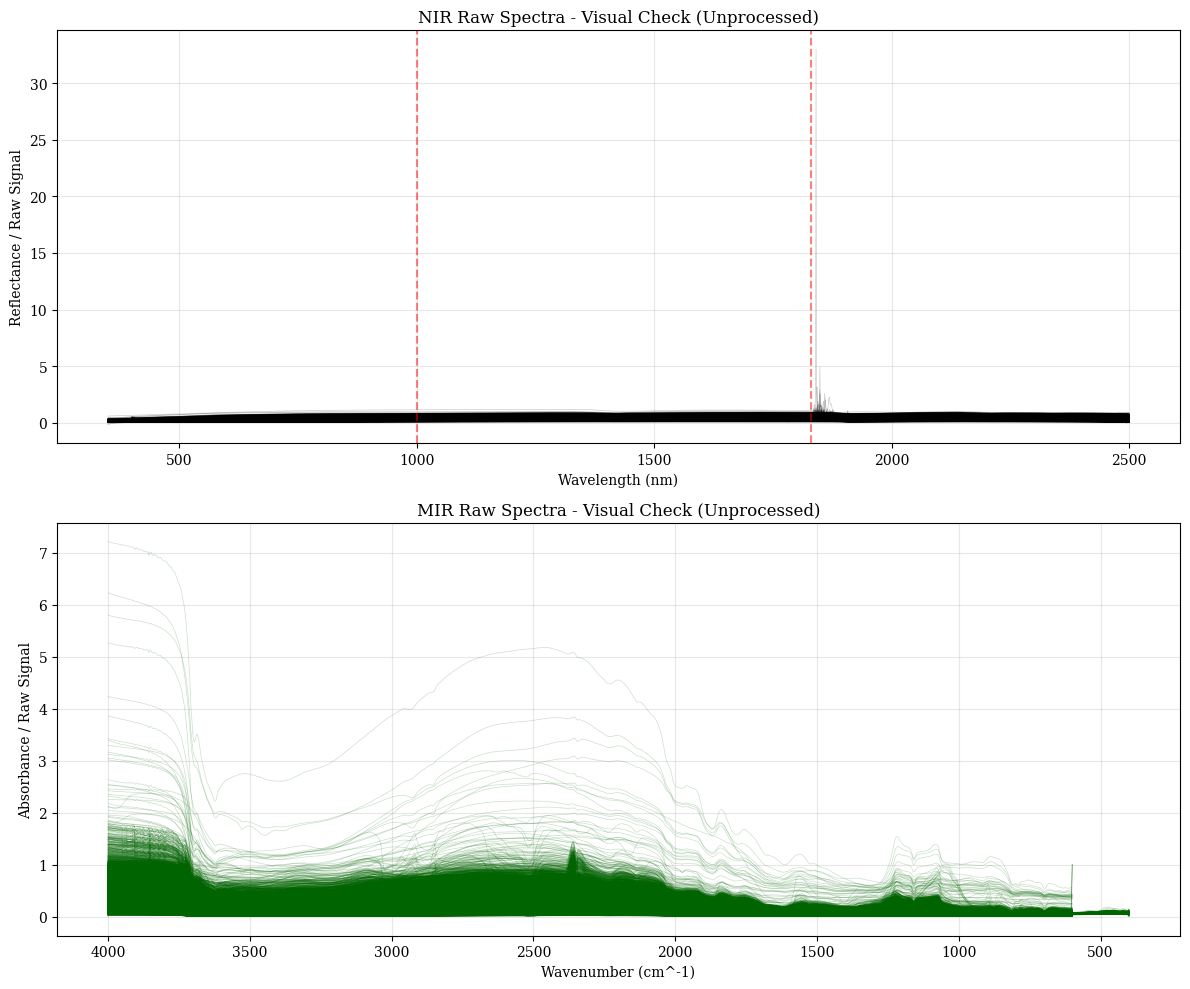

Number of NIR samples detected: 40137
NIR range: 350.0 to 2500.0 nm
Number of MIR samples detected: 49945
MIR range: 400.0 to 4000.0 cm^-1


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Visual style configuration ---
plt.rcParams['font.family'] = 'serif'

# --- Paths and reading  ---
ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == "notebookprojetos_phyton_geocis" else Path.cwd().resolve()
print(ROOT)
def locate_dataset(name):
    candidate = ROOT / "Data" / name
    if candidate.exists(): return candidate
    matches = list(ROOT.rglob(name))
    if matches: return matches[0]
    raise FileNotFoundError(f"{name!r} not found.")

def read_csv_auto(path):
    for enc in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError: continue
    raise UnicodeDecodeError("Encoding error")

# --- Function to extract RAW data ---
def get_raw_spectral_matrix(df):
    """
    Identifies numeric columns and extracts the unprocessed data matrix.
    """
    pairs = []
    for col in df.columns:
        try:
            wl = float(str(col).strip())
            pairs.append((col, wl))
        except: continue
    
    # Sort by wavelength
    pairs = sorted(pairs, key=lambda x: x[1])
    cols = [c for c, _ in pairs]
    wavelengths = np.array([v for _, v in pairs])
    
    # Y matrix (samples x bands)
    y_raw = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    return wavelengths, y_raw

# --- File loading ---
nir_path = locate_dataset("raw_nir_data_Saturin.csv")
mir_path = locate_dataset("raw_mir_data_Saturin.csv")

df_nir, _ = read_csv_auto(nir_path)
df_mir, _ = read_csv_auto(mir_path)

x_nir, y_nir = get_raw_spectral_matrix(df_nir)
x_mir, y_mir = get_raw_spectral_matrix(df_mir)

# --- Raw spectra visualization (Raw Data) ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. VIS-NIR-SWIR RAW
# We plot all rows. alpha=0.3 helps to visualize curve density.
ax1.plot(x_nir, y_nir.T, color='black', alpha=0.2, linewidth=0.5)
ax1.set_title("NIR Raw Spectra - Visual Check (Unprocessed)")
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Reflectance / Raw Signal")
ax1.grid(True, alpha=0.3)

# Mark critical zones where splicing happens for inspection
ax1.axvline(x=1000, color='red', linestyle='--', alpha=0.5, label="Sensor Shift 1000nm")
ax1.axvline(x=1830, color='red', linestyle='--', alpha=0.5, label="Sensor Shift 1830nm")

# 2. MIR RAW
ax2.plot(x_mir, y_mir.T, color='darkgreen', alpha=0.2, linewidth=0.5)
ax2.set_title("MIR Raw Spectra - Visual Check (Unprocessed)")
ax2.set_xlabel("Wavenumber (cm^-1)")
ax2.set_ylabel("Absorbance / Raw Signal")
ax2.invert_xaxis() # MIR convention
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Quick mini statistics for console ---
print(f"Number of NIR samples detected: {y_nir.shape[0]}")
print(f"NIR range: {x_nir.min()} to {x_nir.max()} nm")
print(f"Number of MIR samples detected: {y_mir.shape[0]}")
print(f"MIR range: {x_mir.min()} to {x_mir.max()} cm^-1")

C:\Users\PC\AppData\Local\Temp\ipykernel_10724\643981261.py:93: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Serif.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Serif.
  func(*args, **kwargs)


Detected NIR encoding: latin1
Detected MIR encoding: utf-8
VIS-NIR-SWIR: 2151 bands in 350â€“2500 nm
MIR: 901 bands in 4000â€“400 cmâ»Â¹


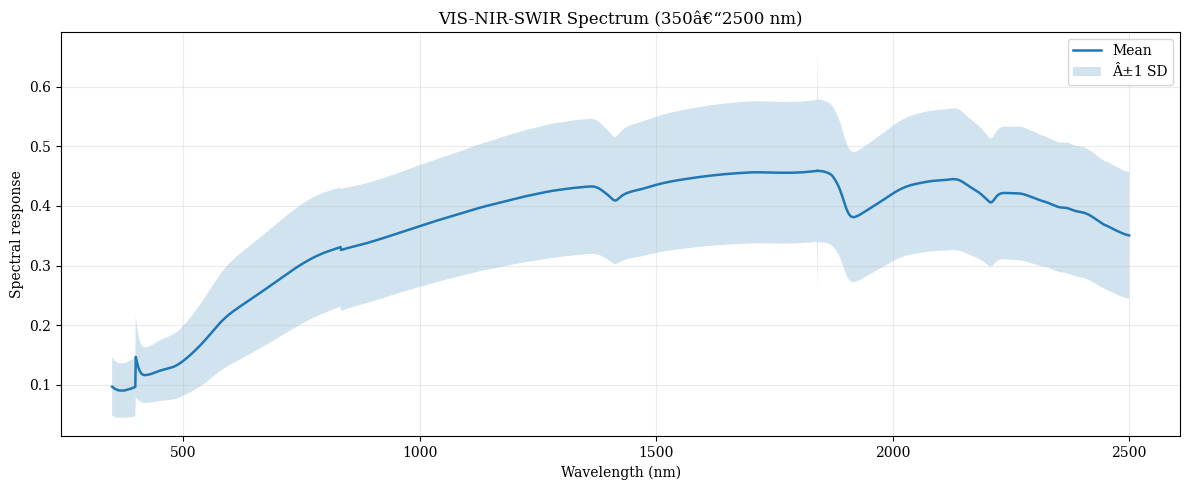

c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


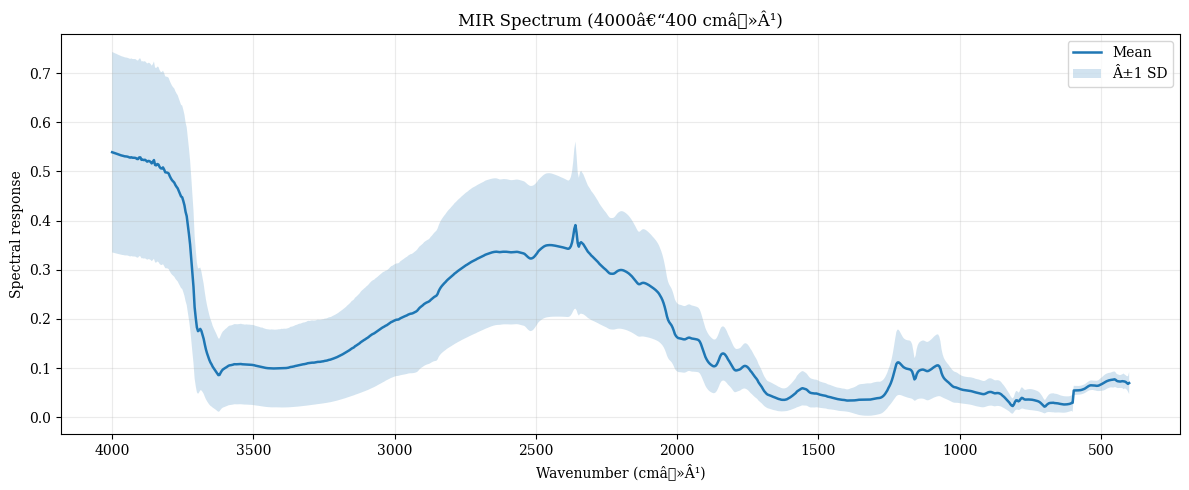

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths ---
ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == "NotebookProjetos_phyton_GeoCIS" else Path.cwd().resolve()

def locate_dataset(name):
    """
    return a Path pointing to `name` somewhere under ROOT.
    look first inside ROOT/Data, then at ROOT, then recurse.
    """
    candidate = ROOT / "Data" / name
    if candidate.exists():
        return candidate
    candidate = ROOT / name
    if candidate.exists():
        return candidate
    matches = list(ROOT.rglob(name))
    if matches:
        print(f"found {name!r} at {matches[0]}")
        return matches[0]
    raise FileNotFoundError(
        f"{name!r} was not found under {ROOT!r}. "
        "Please download the CSV and place it in a `Data` subfolder "
        "of the working directory or adjust `ROOT` accordingly."
    )

nir_path = locate_dataset("raw_nir_data_Saturin.csv")
mir_path = locate_dataset("raw_mir_data_Saturin.csv")

# --- Robust data loading ---
def read_csv_auto(path):
    for enc in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("Could not decode file", b"", 0, 1, "unsupported encoding")

df_nir, enc_nir = read_csv_auto(nir_path)
df_mir, enc_mir = read_csv_auto(mir_path)

# --- Utilities ---
def get_numeric_spectral_cols(df):
    pairs = []
    for col in df.columns:
        try:
            wl = float(str(col).strip())
            pairs.append((col, wl))
        except Exception:
            continue
    return pairs

def subset_spectral(df, low, high):
    pairs = get_numeric_spectral_cols(df)
    pairs = [(c, v) for c, v in pairs if low <= v <= high]
    pairs = sorted(pairs, key=lambda x: x[1])
    cols = [c for c, _ in pairs]
    x = np.array([v for _, v in pairs], dtype=float)
    y = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    mean = np.nanmean(y, axis=0)
    std = np.nanstd(y, axis=0)
    return x, mean, std

# --- 1) VIS-NIR-SWIR: 350â€“2500 nm ---
x_vis, mean_vis, std_vis = subset_spectral(df_nir, 350, 2500)

# --- 2) MIR: 4000â€“400 cm^-1 ---
x_mir, mean_mir, std_mir = subset_spectral(df_mir, 400, 4000)

# --- Separate plots ---
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(x_vis, mean_vis, linewidth=1.8, label="Mean")
ax1.fill_between(x_vis, mean_vis - std_vis, mean_vis + std_vis, alpha=0.2, label="Â±1 SD")
ax1.set_title("VIS-NIR-SWIR Spectrum (350â€“2500 nm)")
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Spectral response")
ax1.grid(alpha=0.25)
ax1.legend()
plt.tight_layout()

fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(x_mir, mean_mir, linewidth=1.8, label="Mean")
ax2.fill_between(x_mir, mean_mir - std_mir, mean_mir + std_mir, alpha=0.2, label="Â±1 SD")
ax2.set_title("MIR Spectrum (4000â€“400 cmâ»Â¹)")
ax2.set_xlabel("Wavenumber (cmâ»Â¹)")
ax2.set_ylabel("Spectral response")
ax2.invert_xaxis()  # usual MIR convention
ax2.grid(alpha=0.25)
ax2.legend()
plt.tight_layout()

print(f"Detected NIR encoding: {enc_nir}")
print(f"Detected MIR encoding: {enc_mir}")
print(f"VIS-NIR-SWIR: {len(x_vis)} bands in 350â€“2500 nm")
print(f"MIR: {len(x_mir)} bands in 4000â€“400 cmâ»Â¹")

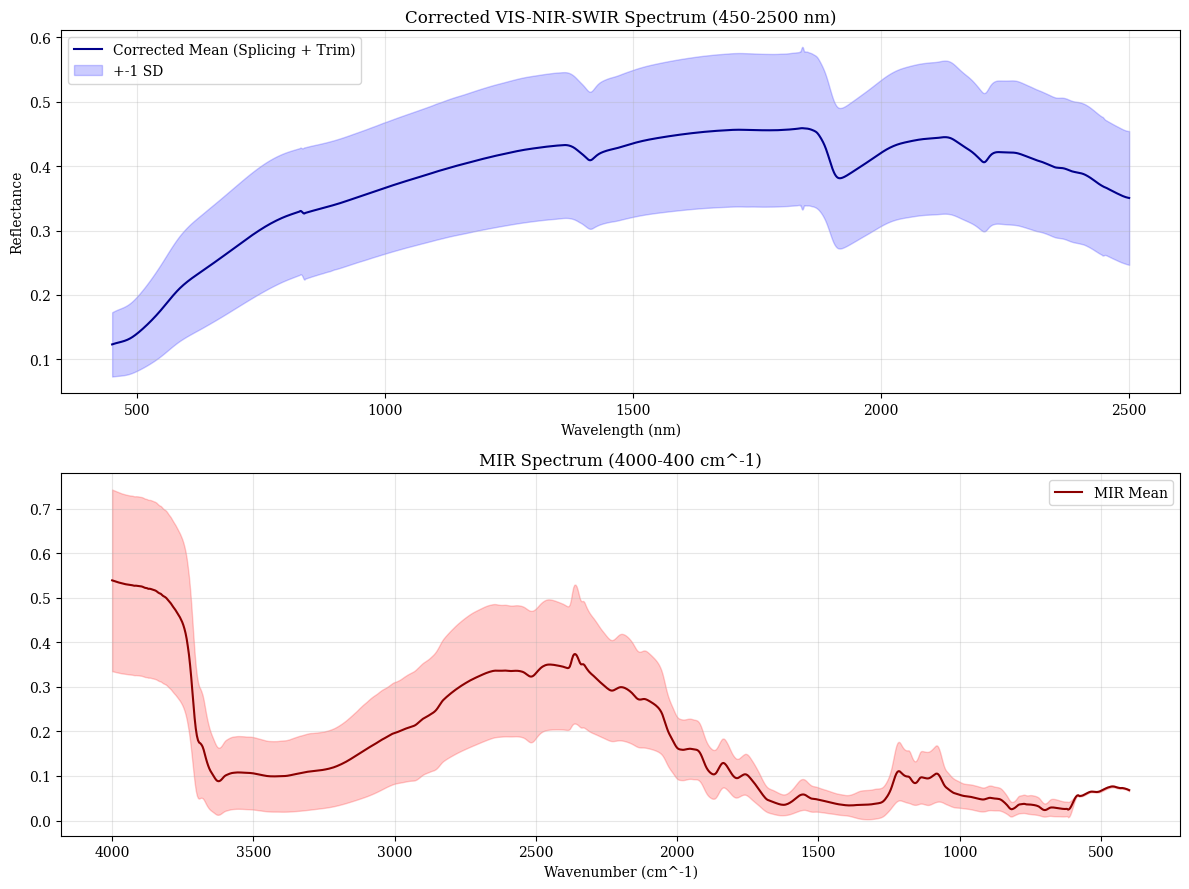


--- VIS-NIR Statistical Summary (Key Bands) ---
 Wavelength     Mean   Median      Std      Min      Max      CV_%
      500.0 0.139864 0.136141 0.057568 0.015659 0.781635 41.160185
     1000.0 0.366142 0.368253 0.101996 0.053076 1.145288 27.857001
     1400.0 0.416941 0.421784 0.107922 0.064676 1.052365 25.884134
     1900.0 0.400281 0.407482 0.111284 0.049996 0.932354 27.801545
     2200.0 0.409920 0.415742 0.108218 0.062517 0.927872 26.399859

--- Global Spectral Statistics ---
NIR - Total mean: 0.3796, Average CV: 28.78%
MIR - Total mean: 0.1757, Average CV: 53.20%
Detected NIR encoding: latin1
Detected MIR encoding: utf-8


In [3]:
# Revised code: complete descriptive analysis of VIS-NIR-SWIR and MIR spectra.
# Includes robust data loading, trimming, splicing correction (placeholder),
# smoothing, and per-band statistics.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- Visual style configuration -----------------------------------------------
plt.rcParams['font.family'] = 'serif'

# --- Path and reading utilities ------------------------------------------------
ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == "notebookprojetos_phyton_geocis" else Path.cwd().resolve()

def locate_dataset(name):
    candidate = ROOT / "Data" / name
    if candidate.exists():
        return candidate
    matches = list(ROOT.rglob(name))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"{name!r} not found under {ROOT!r}")


def read_csv_auto(path):
    for enc in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("Could not decode file", b"", 0, 1, "unsupported encoding")

# --- Spectral processing -------------------------------------------------------

def get_numeric_spectral_cols(df):
    pairs = []
    for col in df.columns:
        try:
            wl = float(str(col).strip())
            pairs.append((col, wl))
        except Exception:
            continue
    return pairs


def apply_splicing_correction(wavelengths, y):
    """Placeholder for splicing correction.
    Returns unchanged data; replace with your algorithm if available.
    """
    return y


def process_spectral_data(df, low, high, do_splice=False, smooth=True):
    """Trims, corrects (optional), smooths, and computes per-band statistics.

    Parameters
    ----------
    df : pandas.DataFrame
        Data with numeric wavelength columns.
    low, high : float
        Lower and upper limits of the band range to keep.
    do_splice : bool
        If True, applies `apply_splicing_correction`.
    smooth : bool
        If True, applies a Savitzky-Golay filter.

    Returns
    -------
    wl : np.ndarray
        Wavelength vector.
    y_proc : np.ndarray
        Processed matrix (samples x bands).
    stats : pandas.DataFrame
        Descriptive statistics per band.
    """
    pairs = get_numeric_spectral_cols(df)
    pairs = [(c, v) for c, v in pairs if low <= v <= high]
    pairs = sorted(pairs, key=lambda x: x[1])
    cols = [c for c, _ in pairs]
    wl = np.array([v for _, v in pairs], dtype=float)

    y_raw = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    y_proc = y_raw.copy()
    if do_splice:
        y_proc = apply_splicing_correction(wl, y_proc)

    # replace inf/NaN with column means
    y_proc = np.where(np.isfinite(y_proc), y_proc, np.nan)
    if np.isnan(y_proc).any():
        col_mean = np.nanmean(y_proc, axis=0)
        inds = np.where(np.isnan(y_proc))
        y_proc[inds] = np.take(col_mean, inds[1])

    if smooth:
        y_proc = savgol_filter(y_proc, window_length=11, polyorder=2, axis=1)

    stats = pd.DataFrame({
        "Wavelength": wl,
        "Mean": np.nanmean(y_proc, axis=0),
        "Median": np.nanmedian(y_proc, axis=0),
        "Std": np.nanstd(y_proc, axis=0),
        "Min": np.nanmin(y_proc, axis=0),
        "Max": np.nanmax(y_proc, axis=0),
    })
    stats["CV_%"] = np.where(stats["Mean"] != 0, stats["Std"] / stats["Mean"] * 100, np.nan)
    return wl, y_proc, stats

# --- Data loading --------------------------------------------------------------
nir_path = locate_dataset("raw_nir_data_Saturin.csv")
mir_path = locate_dataset("raw_mir_data_Saturin.csv")
df_nir, enc_nir = read_csv_auto(nir_path)
df_mir, enc_mir = read_csv_auto(mir_path)

# process
x_vis, y_vis, stats_vis = process_spectral_data(df_nir, 450, 2500, do_splice=True)
x_mir, y_mir, stats_mir = process_spectral_data(df_mir, 400, 4000, do_splice=False)

# --- Visualization --------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

mean_vis = stats_vis["Mean"]
std_vis = stats_vis["Std"]
ax1.plot(x_vis, mean_vis, color="darkblue", label="Corrected Mean (Splicing + Trim)")
ax1.fill_between(x_vis, mean_vis - std_vis, mean_vis + std_vis, color="blue", alpha=0.2, label="+-1 SD")
ax1.set_title("Corrected VIS-NIR-SWIR Spectrum (450-2500 nm)")
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Reflectance")
ax1.legend()
ax1.grid(True, alpha=0.3)

mean_m = stats_mir["Mean"]
std_m = stats_mir["Std"]
ax2.plot(x_mir, mean_m, color="darkred", label="MIR Mean")
ax2.fill_between(x_mir, mean_m - std_m, mean_m + std_m, color="red", alpha=0.2)
ax2.set_title("MIR Spectrum (4000-400 cm^-1)")
ax2.set_xlabel("Wavenumber (cm^-1)")
ax2.invert_xaxis()
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistical summaries ------------------------------------------------------
print("\n--- VIS-NIR Statistical Summary (Key Bands) ---")
bandas_clave = [500, 1000, 1400, 1900, 2200]
resumen = stats_vis[stats_vis["Wavelength"].isin(bandas_clave)]
print(resumen.to_string(index=False))

print("\n--- Global Spectral Statistics ---")
print(f"NIR - Total mean: {stats_vis['Mean'].mean():.4f}, Average CV: {stats_vis['CV_%'].mean():.2f}%")
print(f"MIR - Total mean: {stats_mir['Mean'].mean():.4f}, Average CV: {stats_mir['CV_%'].mean():.2f}%")

print(f"Detected NIR encoding: {enc_nir}")
print(f"Detected MIR encoding: {enc_mir}")

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths ---
ROOT = Path.cwd().resolve()

def read_csv_auto(path):
    for enc in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except: continue
    return None

# --- Splicing function (plate stitching) ---
def corregir_splicing_final(wavelengths, data_matrix):
    """
    Corrects jumps at 1000 and 1830 nm.
    """
    # Create a copy so we can modify it without read-only errors
    corrected = data_matrix.copy()
    
    # Find jump indices
    idx1000 = np.abs(wavelengths - 1000).argmin()
    idx1830 = np.abs(wavelengths - 1830).argmin()
    
    for i in range(corrected.shape[0]):
        row = corrected[i, :]
        
        # 1. Adjust VNIR (350-1000) to SWIR1
        # Use a small average (3 points) so noise does not bias the adjustment
        step1 = np.nanmean(row[idx1000+1:idx1000+4]) / np.nanmean(row[idx1000-2:idx1000+1])
        if np.isfinite(step1):
            corrected[i, :idx1000+1] *= step1
            
        # 2. Adjust SWIR2 (1830-2500) to SWIR1
        step2 = np.nanmean(row[idx1830-2:idx1830+1]) / np.nanmean(row[idx1830+1:idx1830+4])
        if np.isfinite(step2):
            corrected[i, idx1830+1:] *= step2
            
    return corrected

# --- Data loading ---
nir_path = ROOT / "Data" / "raw_nir_data_Saturin.csv"
df_nir = read_csv_auto(nir_path)

if df_nir is not None:
    # Identify numeric columns (wavelengths)
    cols = [c for c in df_nir.columns if c.replace('.','',1).isdigit()]
    wvl = np.array([float(c) for c in cols])
    
    # EXPLANATION OF THE PREVIOUS ERROR:
    # .to_numpy(dtype=float).copy() ensures the array is writable
    y_raw = df_nir[cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float).copy()

    # --- OUTLIER CLEANING (what was flattening the Y axis) ---
    # If a reflectance value is > 2 or < 0, it is a sensor reading error
    y_raw[(y_raw > 2.0) | (y_raw < 0.0)] = np.nan 

    # Remove samples that became entirely empty
    mask = ~np.all(np.isnan(y_raw), axis=1)
    y_clean = y_raw[mask]

    # --- APPLY SPLICING ---
    y_final = corregir_splicing_final(wvl, y_clean)

    # --- PLOTS ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Plot 1: Before splicing (but already without huge values)
    ax1.plot(wvl, y_clean.T, color='black', alpha=0.1, linewidth=0.5)
    ax1.set_title("1. Raw Spectra (Outlier-filtered)")
    ax1.set_ylim(0, 0.8) # Zoom to real soil range
    ax1.grid(True, alpha=0.2)

    # Plot 2: After splicing
    ax2.plot(wvl, y_final.T, color='blue', alpha=0.1, linewidth=0.5)
    ax2.set_title("2. Spectra with Splicing Correction (stitched plates)")
    ax2.set_ylim(0, 0.8)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # --- DESCRIPTIVE STATISTICS ---
    # Create a DataFrame with final data to compute stats easily
    df_final = pd.DataFrame(y_final, columns=wvl)
    estatisticas = df_final.describe().transpose()
    
    # Add Coefficient of Variation (CV%) as in the R code
    estatisticas['CV%'] = (estatisticas['std'] / estatisticas['mean']) * 100
    
    print("\n--- DESCRIPTIVE STATISTICS FOR KEY BANDS ---")
    bandas_interes = [500.0, 1000.0, 1400.0, 1900.0, 2200.0]
    # Find the closest columns to these bands
    cols_stats = [min(wvl, key=lambda x:abs(x-b)) for b in bandas_interes]
    print(estatisticas.loc[cols_stats, ['mean', 'std', 'min', 'max', 'CV%']])

else:
    print("Could not find or read the .csv file")

Could not find or read the .csv file


--- Starting Module 2: Processing ---
--- Starting Module 3: Exploratory Analysis ---
NIR: Mahalanobis with 6 PCs (cum. variance=63.0%)
NIR: detected outliers = 3390 of 40137 (8.45%)
NIR: optimal k by silhouette = 2


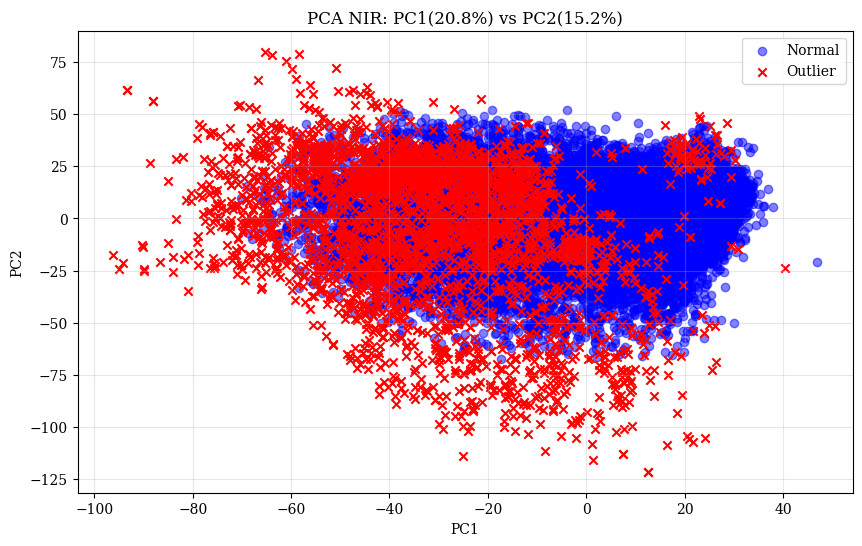

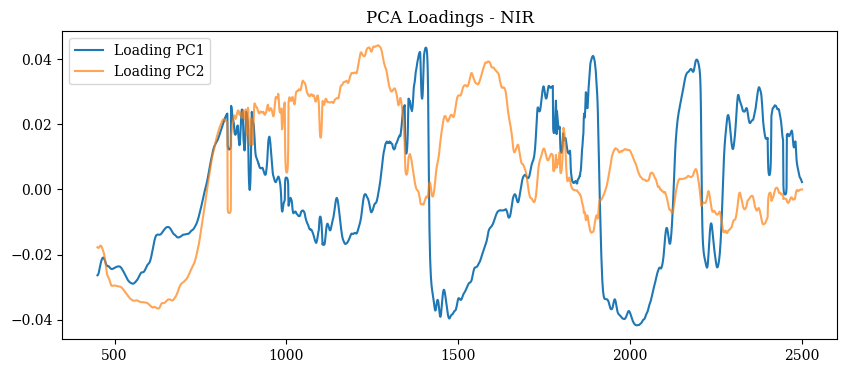

MIR: Mahalanobis with 6 PCs (cum. variance=64.0%)
MIR: detected outliers = 3312 of 49945 (6.63%)
MIR: optimal k by silhouette = 4


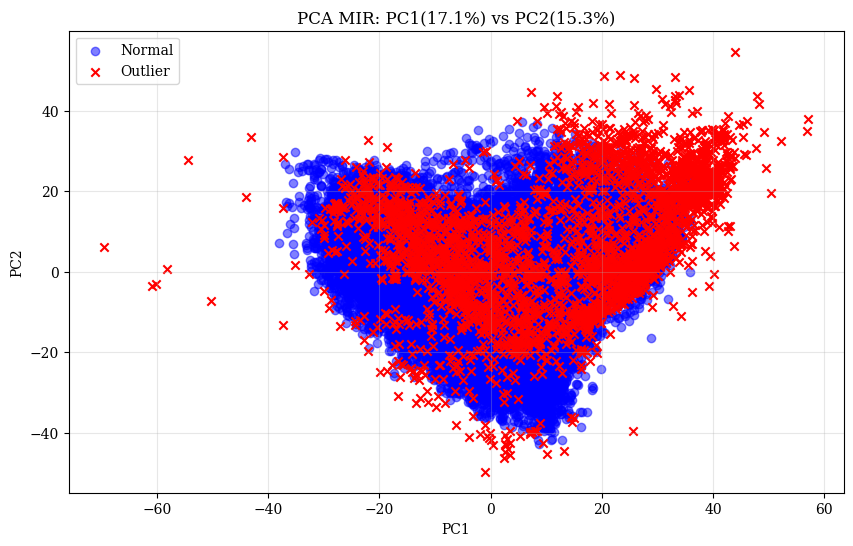

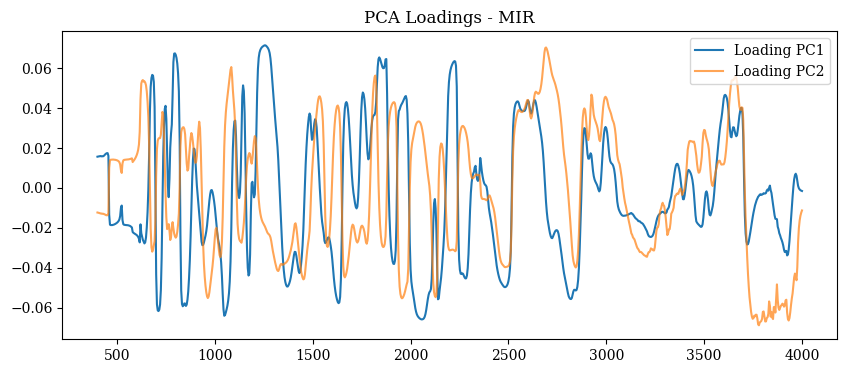

--- Starting Module 4: Clustering ---


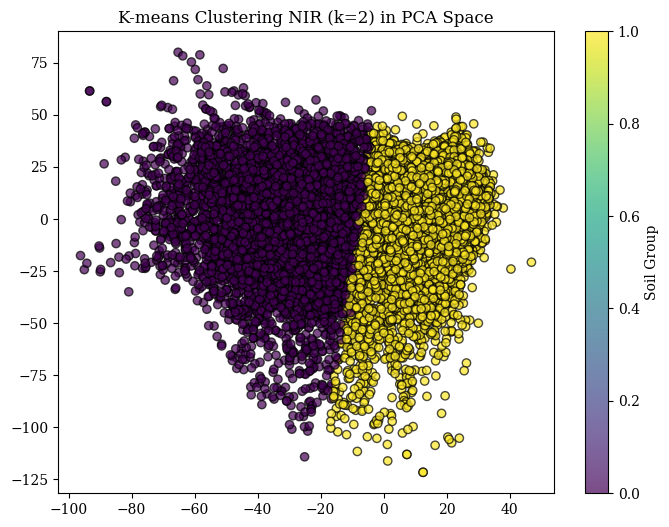

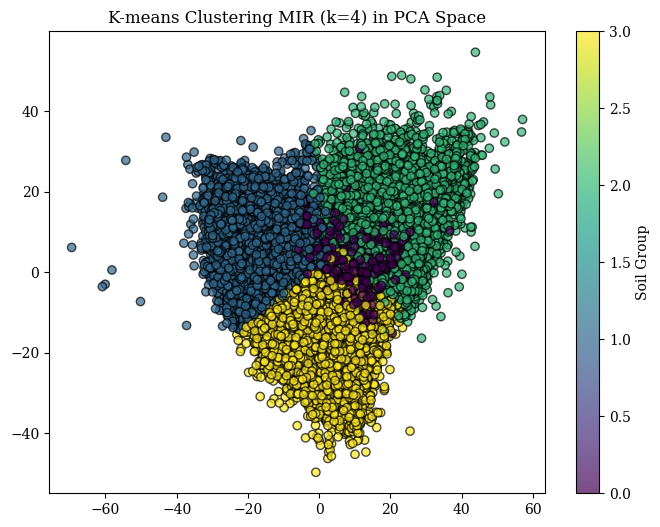

"\n# 1. PROCESSING (Wadoux 5):\n   - SNV: Essential so differences in PCA plots are due to soil CHEMISTRY\n     and not because one sample was more compacted than another.\n   - Derivatives: Remove curve offset (vertical displacement).\n\n2. OUTLIER DETECTION (Ormeno 4.2.1):\n   - We use Mahalanobis Distance. Unlike common distance,\n     it measures how far a point is considering CORRELATION between bands.\n     Points marked with red 'x' are samples GeoCiS should review\n     before training Machine Learning models.\n\n3. LOADINGS (Importance):\n   - The Loadings plot tells you which wavelengths are responsible\n     for moving points in PCA. If you see peaks at 2200nm, clay is dominating.\n\n4. CLUSTERING (Zoning):\n   - K-means creates 'blind' groups. If a group of points consistently falls\n     in the same plot region, they are soils with similar properties that may\n     receive the same fertilization treatment.\n"

In [5]:
# =============================================================================
# GEOCIS PROJECT - SOIL ANALYSIS PIPELINE (NIR & MIR)
# Based on: Wadoux (2021) and Ormeno (2025)
# Modules: 2 (Processing), 3 (Exploratory Analysis), 4 (Clustering)
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.spatial import ConvexHull
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- ROBUST DATA LOADING (so the cell is self-contained) ---
ROOT = Path.cwd().resolve().parent if Path.cwd().name.lower() == "notebookprojetos_phyton_geocis" else Path.cwd().resolve()

def locate_dataset(name):
    candidate = ROOT / "Data" / name
    if candidate.exists():
        return candidate
    matches = list(ROOT.rglob(name))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"{name!r} not found under {ROOT!r}")

def read_csv_auto(path):
    for enc in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("Could not decode file", b"", 0, 1, "unsupported encoding")

def extract_spectral_matrix(df, low=None, high=None):
    pairs = []
    for col in df.columns:
        try:
            wl = float(str(col).strip())
            pairs.append((col, wl))
        except Exception:
            continue

    if low is not None and high is not None:
        pairs = [(c, w) for c, w in pairs if low <= w <= high]

    pairs = sorted(pairs, key=lambda x: x[1])
    cols = [c for c, _ in pairs]
    wavelengths = np.array([w for _, w in pairs], dtype=float)
    matrix = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

    # clean NaN/Inf to avoid SNV and PCA failures
    matrix = np.where(np.isfinite(matrix), matrix, np.nan)
    valid_rows = ~np.all(np.isnan(matrix), axis=1)
    matrix = matrix[valid_rows]
    if np.isnan(matrix).any():
        col_mean = np.nanmean(matrix, axis=0)
        inds = np.where(np.isnan(matrix))
        matrix[inds] = np.take(col_mean, inds[1])

    return wavelengths, matrix

nir_path = locate_dataset("raw_nir_data_Saturin.csv")
mir_path = locate_dataset("raw_mir_data_Saturin.csv")
df_nir = read_csv_auto(nir_path)
df_mir = read_csv_auto(mir_path)

wvl, y_nir_clean = extract_spectral_matrix(df_nir, 450, 2500)
x_mir, y_mir_clean = extract_spectral_matrix(df_mir, 400, 4000)

# --- SUPPORT FUNCTIONS ---

# --- 5.6.2 Continuum Removal ---

# For absorbance spectra, CR gives value of 0 to all parts of
# the spectrum that lie on the convex hull and values between 0 and 1 to regions
# inside absorption bands. The opposite is true if we are dealing with reflectance data.


def apply_snv(data):
    """SNV normalization: corrects scattering according to Wadoux 5.2.1."""
    return (data - np.mean(data, axis=1, keepdims=True)) / (np.std(data, axis=1, keepdims=True) + 1e-9)

def continuum_removal(wavelengths, data):
    """Continuum Removal using convex hull."""
    cr_matrix = np.zeros(data.shape)
    for i in range(data.shape[0]):
        spectrum = data[i, :]
        points = np.column_stack((wavelengths, spectrum))
        hull = ConvexHull(points)
        vertices = sorted(hull.vertices)
        continuum = np.interp(wavelengths, wavelengths[vertices], spectrum[vertices])
        cr_matrix[i, :] = spectrum / (continuum + 1e-12)
    return cr_matrix

# we will use a function upon a specific NIR wavelength region where the secondary clay
# mineral kaolinite can be detected. This region is between 2079 and 2277nm (Clark et al. 2007).
# Wadoux, 2021. p. 77.

OUTLIER_THRESHOLD_PROB = 0.99
TARGET_CUMVAR_PCT = 80.0

# --- Mahalanobis distance ---

# Spectral outlier detection was based on the Mahalanobis distance between
# each observation's scores and the centroid of PCA space. As a classification criterion,
# a threshold equivalent to the 99th percentile of all accumulated distances was set,
# and samples above that value were considered potential outliers.
# def detect_outliers_mahalanobis(scores, threshold_prob=OUTLIER_THRESHOLD_PROB):

def detect_outliers_mahalanobis(scores, threshold_prob=OUTLIER_THRESHOLD_PROB):
    """Multivariate outlier detection on PCA scores (Ormeno 3.5)."""
    mu = np.mean(scores, axis=0)
    cov = np.cov(scores, rowvar=False)
    inv_cov = np.linalg.pinv(cov)

    mahal_dist = []
    for s in scores:
        d = (s - mu).T @ inv_cov @ (s - mu)
        mahal_dist.append(d)

    # Chi-square threshold with df = number of PCs used.
    threshold = stats.chi2.ppf(threshold_prob, df=scores.shape[1])
    return np.array(mahal_dist), threshold

# NOTE: The number of PCs for Mahalanobis is selected based on cumulative variance (Wadoux/Ormeno).

# =============================================================================
# MODULE 2: INTEGRATED SPECTRAL PROCESSING
# =============================================================================
print("--- Starting Module 2: Processing ---")

# 2.1 NIR Pipeline: SNV + Savitzky-Golay (1st Derivative)
y_nir_snv = apply_snv(y_nir_clean)
y_nir_der = savgol_filter(y_nir_snv, window_length=11, polyorder=2, deriv=1, axis=1)

# 2.2 MIR Pipeline
y_mir_snv = apply_snv(y_mir_clean)
y_mir_der = savgol_filter(y_mir_snv, window_length=11, polyorder=2, deriv=1, axis=1)

# 2.3 Continuum Removal (CR)
y_nir_cr = continuum_removal(wvl, y_nir_clean)

# Working variables used in PCA
y_nir_proc = y_nir_der
y_mir_proc = y_mir_der

# =============================================================================
# MODULE 3: EXPLORATORY ANALYSIS (PCA AND OUTLIERS)
# =============================================================================
print("--- Starting Module 3: Exploratory Analysis ---")

def select_k_by_silhouette(scores, k_min=2, k_max=8, max_pc=3):
    X = scores[:, :min(max_pc, scores.shape[1])]
    k_max = min(k_max, X.shape[0] - 1)
    if k_max < k_min:
        return 2, []

    k_values = list(range(k_min, k_max + 1))
    sil_scores = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sil_scores.append(silhouette_score(X, labels))

    best_k = k_values[int(np.argmax(sil_scores))]
    return best_k, list(zip(k_values, sil_scores))

def full_pca_analysis(data, wavelengths, sensor_name):
    X_scaled = StandardScaler().fit_transform(data)

    n_comp = min(10, X_scaled.shape[0], X_scaled.shape[1])
    pca = PCA(n_components=n_comp)
    scores = pca.fit_transform(X_scaled)
    loadings = pca.components_
    var_exp = pca.explained_variance_ratio_ * 100

    # Select PCs for Mahalanobis by cumulative variance (Wadoux/Ormeno).
    cum_var = np.cumsum(var_exp)
    k_md = np.searchsorted(cum_var, TARGET_CUMVAR_PCT) + 1
    k_md = max(2, min(k_md, min(6, scores.shape[1])))
    scores_md = scores[:, :k_md]

    dists, limit = detect_outliers_mahalanobis(scores_md, threshold_prob=OUTLIER_THRESHOLD_PROB)
    is_outlier = dists > limit
    print(f"{sensor_name}: Mahalanobis with {k_md} PCs (cum. variance={cum_var[k_md-1]:.1f}%)")
    print(f"{sensor_name}: detected outliers = {is_outlier.sum()} of {len(is_outlier)} ({100*is_outlier.mean():.2f}%)")

    # Automatic k for clustering using non-outlier samples.
    scores_for_k = scores[~is_outlier] if (~is_outlier).sum() >= 20 else scores
    k_best, k_table = select_k_by_silhouette(scores_for_k, k_min=2, k_max=8, max_pc=3)
    print(f"{sensor_name}: optimal k by silhouette = {k_best}")

    plt.figure(figsize=(10, 6))
    plt.scatter(scores[~is_outlier, 0], scores[~is_outlier, 1], c='blue', alpha=0.5, label='Normal')
    plt.scatter(scores[is_outlier, 0], scores[is_outlier, 1], c='red', marker='x', label='Outlier')
    plt.title(f"PCA {sensor_name}: PC1({var_exp[0]:.1f}%) vs PC2({var_exp[1]:.1f}%)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(wavelengths, loadings[0, :], label='Loading PC1')
    plt.plot(wavelengths, loadings[1, :], label='Loading PC2', alpha=0.7)
    plt.title(f"PCA Loadings - {sensor_name}")
    plt.legend()
    plt.show()

    return scores, is_outlier, k_best

scores_nir, out_nir, k_nir = full_pca_analysis(y_nir_proc, wvl, "NIR")
scores_mir, out_mir, k_mir = full_pca_analysis(y_mir_proc, x_mir, "MIR")

# =============================================================================
# MODULE 4: CLUSTERING (K-MEANS)
# =============================================================================
print("--- Starting Module 4: Clustering ---")

def apply_clustering(scores, sensor_name, n_clusters=4):
    n_clusters = min(n_clusters, max(2, scores.shape[0] - 1))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(scores[:, :min(3, scores.shape[1])])

    plt.figure(figsize=(8, 6))
    plt.scatter(scores[:, 0], scores[:, 1], c=clusters, cmap='viridis', edgecolors='k', alpha=0.7)
    plt.title(f"K-means Clustering {sensor_name} (k={n_clusters}) in PCA Space")
    plt.colorbar(label="Soil Group")
    plt.show()
    return clusters

cluster_labels_nir = apply_clustering(scores_nir, "NIR", n_clusters=k_nir)
cluster_labels_mir = apply_clustering(scores_mir, "MIR", n_clusters=k_mir)
cluster_labels = cluster_labels_nir

# =============================================================================
# STEP-BY-STEP EXPLANATION FOR VSCODE (GEOCIS):
# =============================================================================
#
"""
# 1. PROCESSING (Wadoux 5):
   - SNV: Essential so differences in PCA plots are due to soil CHEMISTRY
     and not because one sample was more compacted than another.
   - Derivatives: Remove curve offset (vertical displacement).

2. OUTLIER DETECTION (Ormeno 4.2.1):
   - We use Mahalanobis Distance. Unlike common distance,
     it measures how far a point is considering CORRELATION between bands.
     Points marked with red 'x' are samples GeoCiS should review
     before training Machine Learning models.

3. LOADINGS (Importance):
   - The Loadings plot tells you which wavelengths are responsible
     for moving points in PCA. If you see peaks at 2200nm, clay is dominating.

4. CLUSTERING (Zoning):
   - K-means creates 'blind' groups. If a group of points consistently falls
     in the same plot region, they are soils with similar properties that may
     receive the same fertilization treatment.
"""

--- Cluster number validation (NIR) ---
Optimal k by silhouette: 2
k=2: silhouette=0.3856
k=3: silhouette=0.3192
k=4: silhouette=0.3303
k=5: silhouette=0.2828
k=6: silhouette=0.2823
k=7: silhouette=0.2921
k=8: silhouette=0.2720


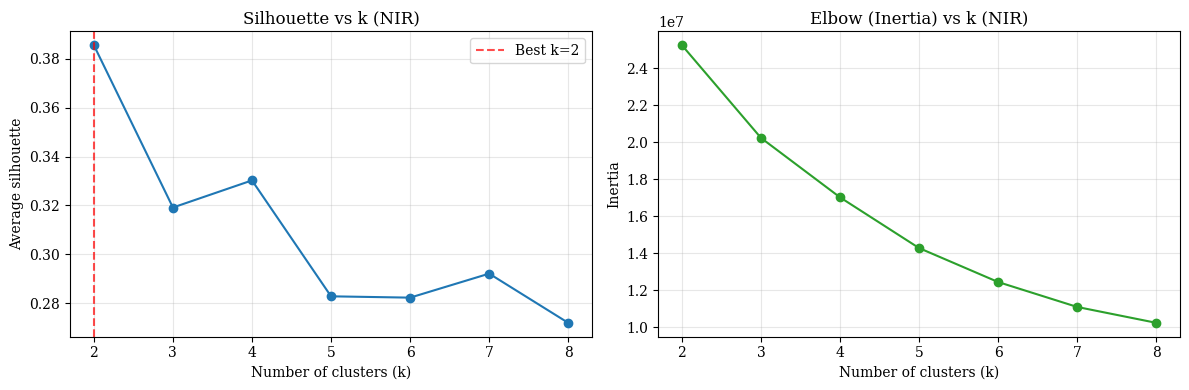

--- Cluster number validation (MIR) ---
Optimal k by silhouette: 2
k=2: silhouette=0.3740
k=3: silhouette=0.3032
k=4: silhouette=0.3531
k=5: silhouette=0.3304
k=6: silhouette=0.3149
k=7: silhouette=0.3026
k=8: silhouette=0.3012


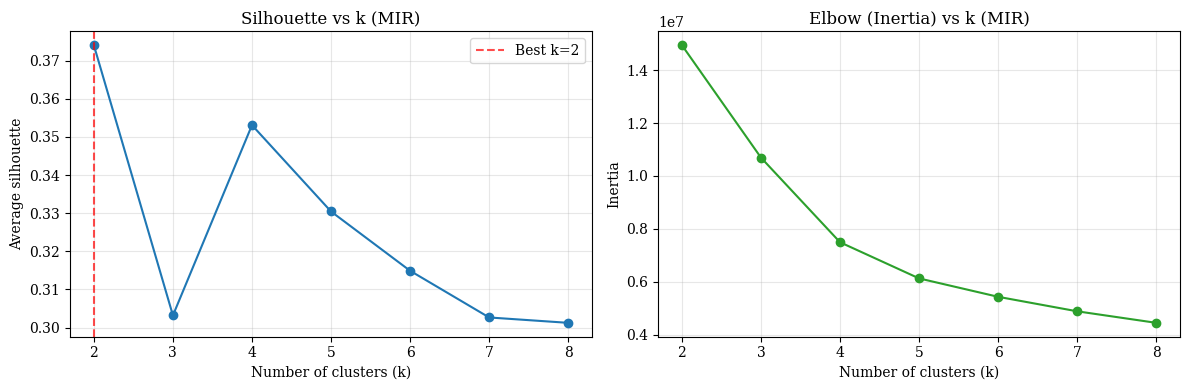

Final summary -> NIR: k=2 | MIR: k=2


In [6]:
# k validation (Wadoux/Ormeno): silhouette + elbow on PCA scores
from sklearn.metrics import silhouette_score

def validate_k_scores(scores, sensor_name, max_pc=3, k_min=2, k_max=8):
    X_cluster = scores[:, :min(max_pc, scores.shape[1])]
    k_values = list(range(k_min, k_max + 1))
    sil_scores = []
    inertias = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_cluster)
        sil_scores.append(silhouette_score(X_cluster, labels))
        inertias.append(km.inertia_)

    best_k = k_values[int(np.argmax(sil_scores))]
    print(f"--- Cluster number validation ({sensor_name}) ---")
    print(f"Optimal k by silhouette: {best_k}")
    for k, s in zip(k_values, sil_scores):
        print(f"k={k}: silhouette={s:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(k_values, sil_scores, marker='o', color='tab:blue')
    ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f"Best k={best_k}")
    ax1.set_title(f"Silhouette vs k ({sensor_name})")
    ax1.set_xlabel("Number of clusters (k)")
    ax1.set_ylabel("Average silhouette")
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.plot(k_values, inertias, marker='o', color='tab:green')
    ax2.set_title(f"Elbow (Inertia) vs k ({sensor_name})")
    ax2.set_xlabel("Number of clusters (k)")
    ax2.set_ylabel("Inertia")
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_k, k_values, sil_scores, inertias

best_k_nir, _, _, _ = validate_k_scores(scores_nir, "NIR")
best_k_mir, _, _, _ = validate_k_scores(scores_mir, "MIR")
print(f"Final summary -> NIR: k={best_k_nir} | MIR: k={best_k_mir}")

DO NOT RUN THIS ONE, IT IS VERY HEAVY

In [7]:
# DO NOT RUN THIS ONE, IT IS VERY HEAVY
# =============================================================================
# GEOCIS PROJECT - MODULE 5: MODELING AND INTERPRETATION (SHAP)
# Based on: Wadoux (2021) and Vergaray Ormeno (2025)
# Algorithms: PLSR, Random Forest + SHAP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap

# --- METRICS FUNCTION (Based on Vergaray Thesis pp. 166-173) ---
def calculate_soil_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    # RPD (Ratio of Performance to Deviation)
    rpd = np.std(y_true) / rmse
    # RPIQ (Ratio of Performance to Interquartile distance)
    q75, q25 = np.percentile(y_true, [75 ,25])
    rpiq = (q75 - q25) / rmse
    return {"RMSE": rmse, "R2": r2, "MAE": mae, "RPD": rpd, "RPIQ": rpiq}

# --- LIST OF TARGET ATTRIBUTES ---
targets = ["C_gkg", "Clay_gkg"]

# We will use NIR sensor data as an example (you can switch to MIR)
X_all = y_nir_proc  # Spectral matrix already processed in the previous step
df_lab = df_nir      # DataFrame that contains laboratory columns

for target in targets:
    print(f"\n" + "="*50)
    print(f"MODELING ATTRIBUTE: {target}")
    print("="*50)

    # 1. Alignment and missing-data cleaning in lab values
    # It is critical that spectrum and soil value match perfectly
    y_values = df_lab[target].values
    
    # Remove samples where lab value is NaN
    valid_idx = ~np.isnan(y_values)
    X = X_all[valid_idx]
    y = y_values[valid_idx]

    if len(y) < 10:
        print(f"Skipping {target}: too few valid data points.")
        continue

    # 2. Train/Test split (75/25) - Wadoux Ch. 9.1
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    # =========================================================================
    # 3. PLSR MODEL (Wadoux standard)
    # =========================================================================
    # Use 10 components as suggested by Wadoux as a starting point
    pls = PLSRegression(n_components=10)
    pls.fit(X_train, y_train)
    y_pred_pls = pls.predict(X_test).ravel()
    m_pls = calculate_soil_metrics(y_test, y_pred_pls)

    # =========================================================================
    # 4. RANDOM FOREST MODEL (Nonlinear)
    # =========================================================================
    rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    m_rf = calculate_soil_metrics(y_test, y_pred_rf)

    # --- Show results ---
    perf = pd.DataFrame({"PLSR": m_pls, "Random Forest": m_rf}).T
    print(perf.round(3))

    # 5. PREDICTION PLOTS (Observed vs Predicted)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # PLSR plot
    ax[0].scatter(y_test, y_pred_pls, alpha=0.6, c='blue', edgecolors='k')
    ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    ax[0].set_title(f"PLSR - {target}\nR2: {m_pls['R2']:.2f} | RPD: {m_pls['RPD']:.2f}")
    ax[0].set_xlabel("Observed value (Lab)")
    ax[0].set_ylabel("Prediction (Spectral)")

    # RF plot
    ax[1].scatter(y_test, y_pred_rf, alpha=0.6, c='green', edgecolors='k')
    ax[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    ax[1].set_title(f"Random Forest - {target}\nR2: {m_rf['R2']:.2f} | RPD: {m_rf['RPD']:.2f}")
    ax[1].set_xlabel("Observed value (Lab)")
    ax[1].set_ylabel("Prediction (Spectral)")
    plt.show()

    # =========================================================================
    # 6. SHAP INTERPRETATION (Soil chemistry)
    # =========================================================================
    print(f"Calculating chemical importance (SHAP) for {target}...")
    # To save time in VSCode, use 50 test samples for SHAP
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_test[:50])

    plt.figure(figsize=(10, 6))
    # wvl are the sensor wavelengths (e.g., 350-2500)
    shap.summary_plot(shap_vals, X_test[:50], feature_names=wvl.astype(str), 
                      plot_type="bar", max_display=15, show=False)
    plt.title(f"Top 15 most influential bands for {target}")
    plt.show()

ModuleNotFoundError: No module named 'shap'

In [ ]:
RUN THIS ONE

SyntaxError: invalid syntax (1620296297.py, line 1)

In [ ]:
# =============================================================================
# GEOCIS PROJECT - MODULE 5: OPTIMIZED MODELING (PC Friendly)
# Computational load reduction according to Wadoux 5.5.1
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import shap

# --- 1. DATA REDUCTION (to cool down the processor) ---
# Wadoux suggests that 10nm resolution is enough for soils.
# This reduces PC workload from 2000 columns to only 200.
step = 10 
X_all_light = y_nir_proc[:, ::step] 
wvl_light = wvl[::step]

targets = ["C_gkg", "Clay_gkg"]
df_lab = df_nir 

for target in targets:
    print(f"\nProcessing {target} efficiently...")
    
    y_values = df_lab[target].values
    valid_idx = ~np.isnan(y_values)
    X = X_all_light[valid_idx] # Use the reduced matrix
    y = y_values[valid_idx]

    # 75/25 split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    # --- PLSR MODEL (very fast and lightweight) ---
    pls = PLSRegression(n_components=8) # Reduce components for higher speed
    pls.fit(X_train, y_train)
    y_pred_pls = pls.predict(X_test).ravel()
    r2_pls = r2_score(y_test, y_pred_pls)

    # --- RANDOM FOREST MODEL (optimized) ---
    # Lower n_estimators from 500 to 100 to avoid overheating the PC
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    r2_rf = r2_score(y_test, y_pred_rf)

    # --- QUICK PLOT ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_pls, alpha=0.5, c='blue')
    plt.title(f"PLSR {target} (R2: {r2_pls:.2f})")
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred_rf, alpha=0.5, c='green')
    plt.title(f"RF {target} (R2: {r2_rf:.2f})")
    plt.show()

    # --- ULTRA-FAST SHAP ---
    print("Calculating simplified chemical importance...")
    # Use only 20 samples for explanation (enough to see peaks)
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_test[:20])

    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_vals, X_test[:20], feature_names=wvl_light.astype(str), 
                      plot_type="bar", max_display=10, show=False)
    plt.title(f"Key chemical peaks: {target}")
    plt.show()

print("\nDone! The processor should now stay at a normal temperature.")

ModuleNotFoundError: No module named 'shap'